In [123]:
import os
import itertools
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cf

from matplotlib import patches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath(".."))
from function import ART_preprocessing as ART_pre

In [2]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','5_DOWN')

In [101]:
DATA = xr.open_dataset(os.path.join(dir_base,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))

lons = DATA.lon.values
lats = DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)

BETA = DATA.BETA.values
GAMMA = DATA.GAMMA.values
Mev_d = DATA.Mev_d.values[3,:,:]

In [140]:
np.nanmin(GAMMA), np.nanmax(GAMMA)

(0.8824602990901194, 0.9773051285411266)

In [102]:
# lon_min, lon_max, lat_min, lat_max = 10.5, 13.5, 44.5, 47
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'ITALY', 0.002

veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

italy_geom = ITALY.union_all()

In [142]:
Mev_levels = np.arange(40, 320, 10)
Mev_cmap = plt.cm.Spectral_r
Mev_norm = BoundaryNorm(Mev_levels, ncolors=Mev_cmap.N, clip=True)

BETA_levels = np.arange(0.7, 1.4, 0.1)
BETA_cmap = plt.cm.Blues
BETA_norm = BoundaryNorm(BETA_levels, ncolors=BETA_cmap.N, clip=True)

GAMMA_levels = np.arange(0.87, 0.98, 0.01)
GAMMA_cmap = plt.cm.Reds
GAMMA_norm = BoundaryNorm(GAMMA_levels, ncolors=GAMMA_cmap.N, clip=True)

cmap_bin = plt.get_cmap('viridis', 3) 
norm = mcolors.BoundaryNorm([0, 0.5, 1], cmap_bin.N)  

Export figure to: ../fig/gif/ITALY/IT_00000.png
Export figure to: ../fig/gif/ITALY/IT_00001.png
Export figure to: ../fig/gif/ITALY/IT_00002.png
Export figure to: ../fig/gif/ITALY/IT_00003.png
Export figure to: ../fig/gif/ITALY/IT_00004.png
Export figure to: ../fig/gif/ITALY/IT_00005.png
Export figure to: ../fig/gif/ITALY/IT_00006.png
Export figure to: ../fig/gif/ITALY/IT_00007.png
Export figure to: ../fig/gif/ITALY/IT_00008.png
Export figure to: ../fig/gif/ITALY/IT_00009.png
Export figure to: ../fig/gif/ITALY/IT_00010.png
Export figure to: ../fig/gif/ITALY/IT_00011.png
Export figure to: ../fig/gif/ITALY/IT_00012.png
Export figure to: ../fig/gif/ITALY/IT_00013.png
Export figure to: ../fig/gif/ITALY/IT_00014.png
Export figure to: ../fig/gif/ITALY/IT_00015.png
Export figure to: ../fig/gif/ITALY/IT_00016.png
Export figure to: ../fig/gif/ITALY/IT_00017.png
Export figure to: ../fig/gif/ITALY/IT_00018.png
Export figure to: ../fig/gif/ITALY/IT_00019.png
Export figure to: ../fig/gif/ITALY/IT_00

KeyboardInterrupt: 

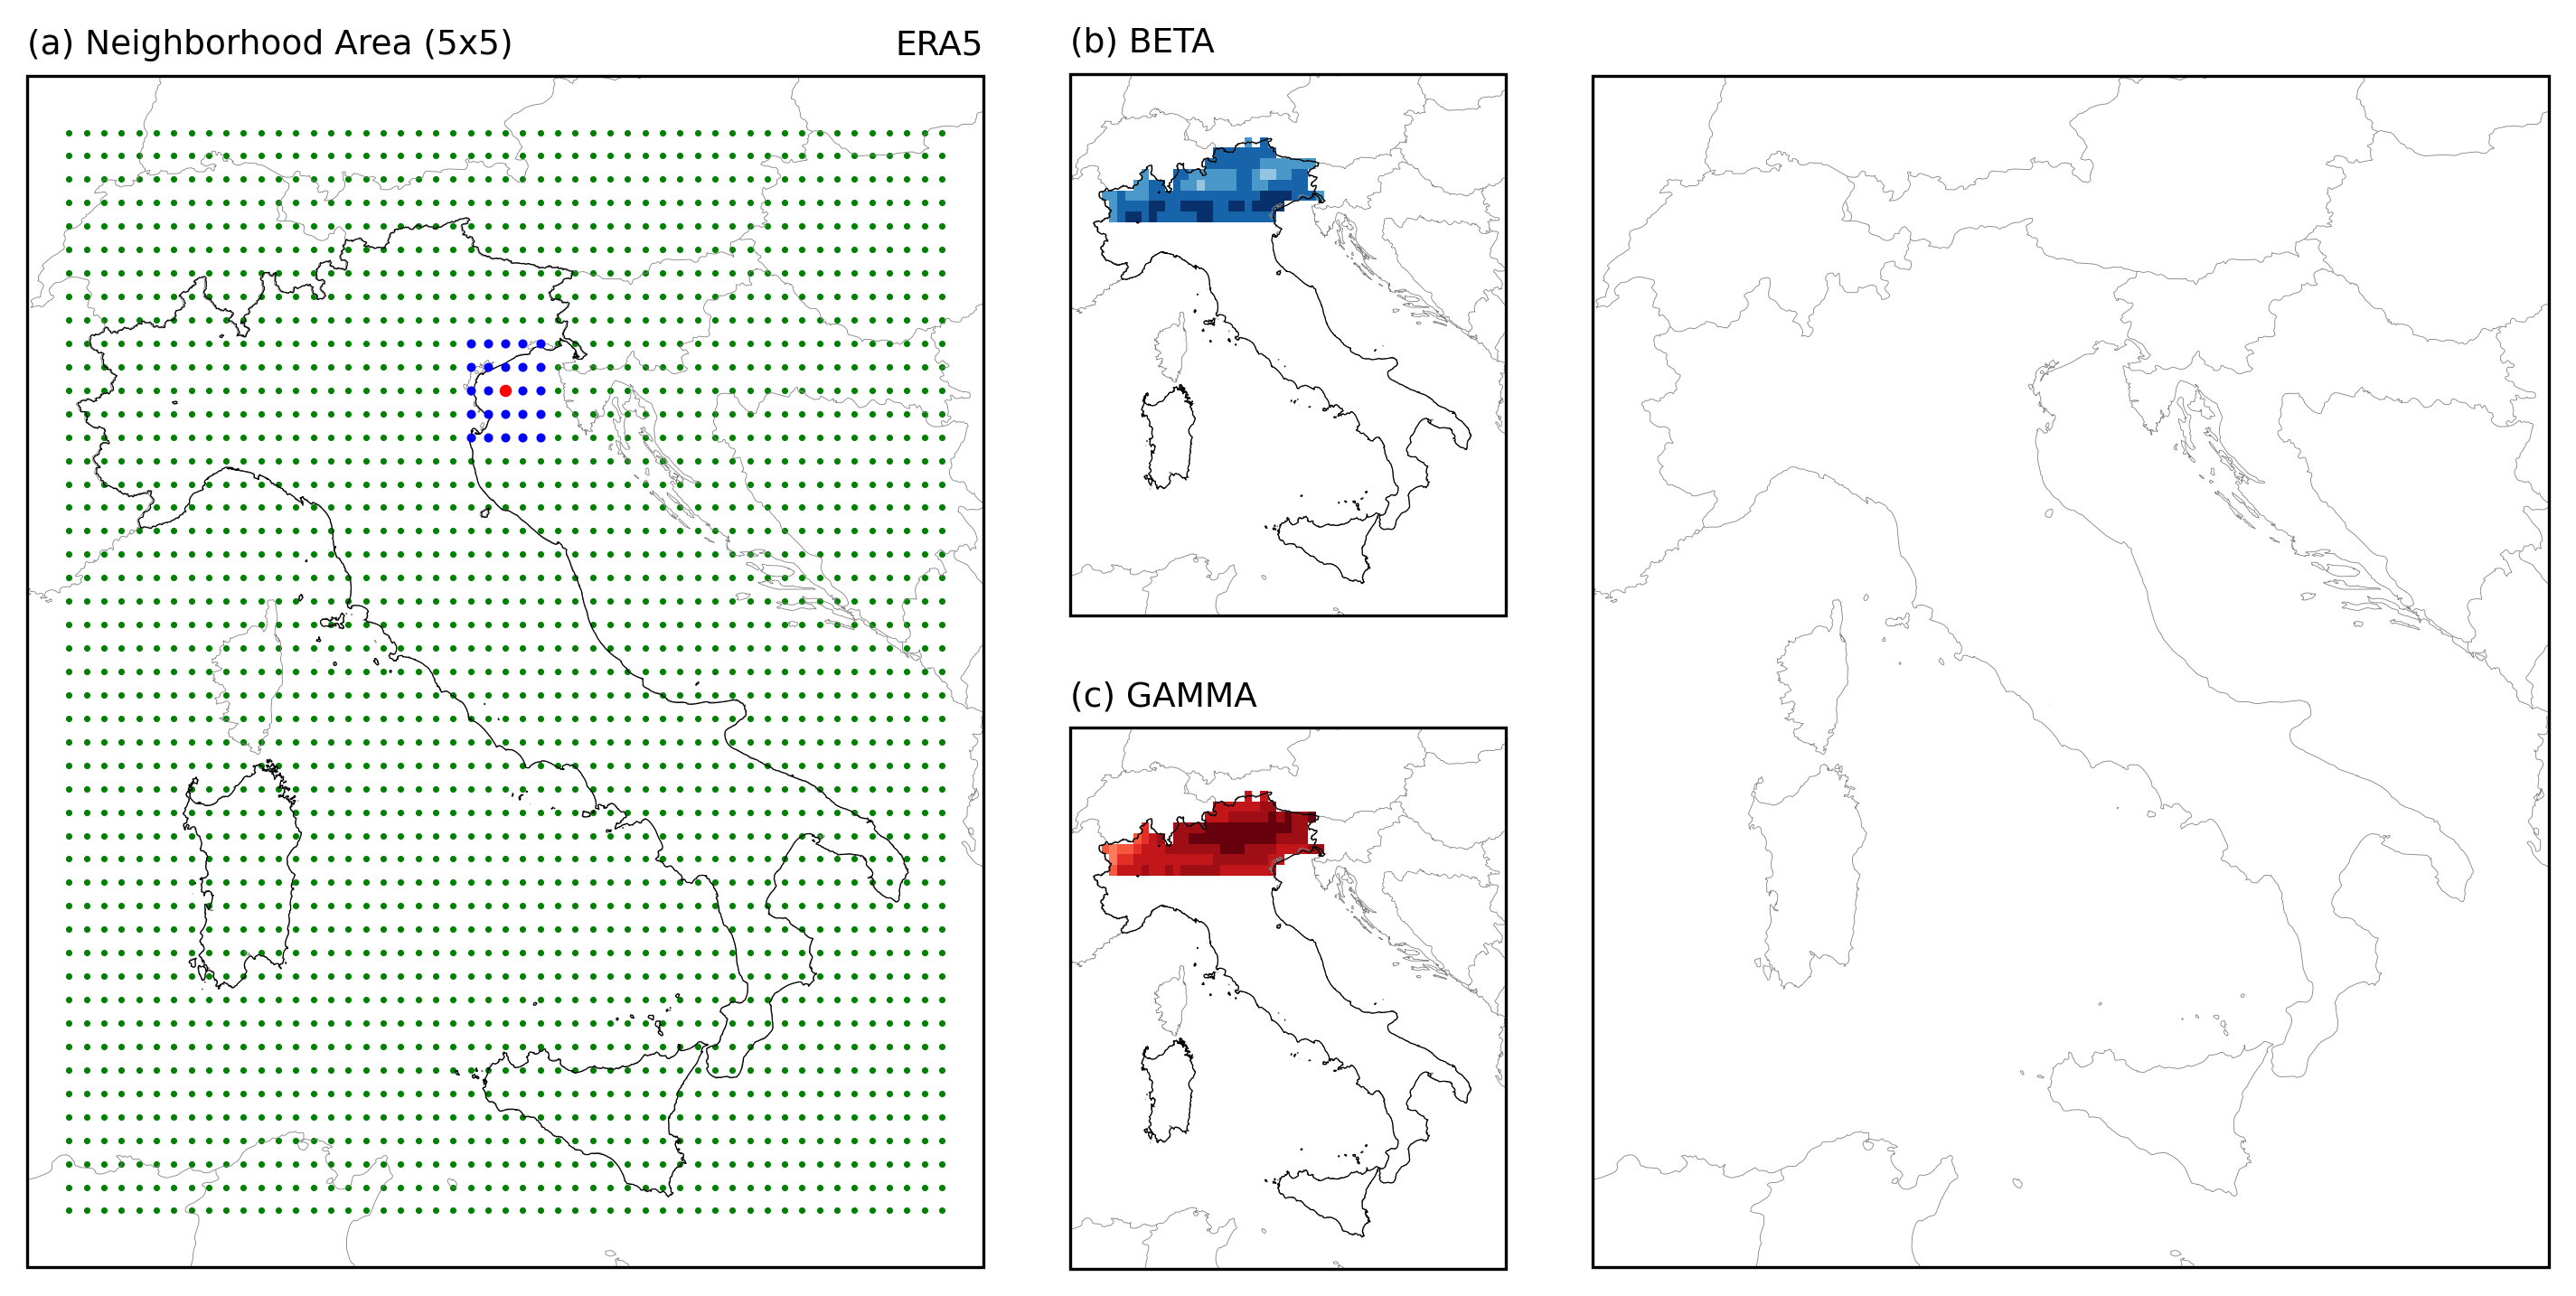

In [143]:
BETA_tmp = np.zeros([len(lats),len(lons)])*np.nan
GAMMA_tmp = np.zeros([len(lats),len(lons)])*np.nan 
Mev_tmp = np.zeros([len(lats),len(lons)])*np.nan

nn = 0
# for i in range(30,32):#range(len(lats))
#     for j in range(25,38):#len(lons)
for i in range(4,len(lats)):
    for j in range(len(lons)):

        lat_c = lats[i]
        lon_c = lons[j]

        point = Point(lon_c, lat_c)
        is_inside = ITALY.contains(point).any()
        
        if is_inside == True:
            BETA_tmp[i,j] = BETA[i,j]
            GAMMA_tmp[i,j] = GAMMA[i,j]
            Mev_tmp[i,j] = Mev_d[i,j]

        BOX = ART_pre.create_box_v2(DATA, lat_c, lon_c, 2)
        lat_box = BOX['lat'].data
        lon_box = BOX['lon'].data
        box_lon2d, box_lat2d = np.meshgrid(lon_box, lat_box)

        proj = ccrs.PlateCarree()

        fig = plt.figure(figsize=(12,12),dpi=300)
        gs = gridspec.GridSpec(4,5)

        # ============================================================================================================================
        ax1 = plt.subplot(gs[0:2, 0:2], projection = proj)
        ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
        ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
        ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
        im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

        ax1.scatter(lon2d, lat2d, s=0.5, c='g', marker='o', label='Study pixels')
        ax1.scatter(box_lon2d, box_lat2d, s=2, c='b', label='Box pixels', zorder=50)
        ax1.scatter(lon_c, lat_c, s=5 , c='r', label='Central pixel', zorder=55)
        
        ax1.set_title('(a) Neighborhood Area (5x5)', loc='left', fontsize=9)
        ax1.set_title('ERA5', loc='right', fontsize=9)

        # ============================================================================================================================
        ax1 = plt.subplot(gs[0, 2], projection = proj)
        ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
        ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
        ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
        im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

        a1 = ax1.pcolormesh(lon2d, lat2d, BETA_tmp, cmap=BETA_cmap, norm=BETA_norm)

        ax1.set_title('(b) BETA', loc='left', fontsize=9)

        # ============================================================================================================================
        ax1 = plt.subplot(gs[1, 2], projection = proj)
        ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
        ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
        ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
        im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

        a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA_tmp, cmap=GAMMA_cmap, norm=GAMMA_norm)

        ax1.set_title('(c) GAMMA', loc='left', fontsize=9)

        # ============================================================================================================================
        ax1 = plt.subplot(gs[0:2, 3:], projection = proj)
        ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
        ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
        ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
        im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

        a1 = ax1.pcolormesh(lon2d, lat2d, Mev_tmp, cmap=Mev_cmap, norm=Mev_norm)

        ax1.set_title('(d) Extreme Quantiles', loc='left', fontsize=9)
        ax1.set_title('Tr = 50 yrs', loc='right', fontsize=9)

        # ============================================================================================================================
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.1, wspace=0.1)

        salida = os.path.join('..','fig','gif','ITALY',f'IT_{str(nn).zfill(5)}.png')
        print(f'Export figure to: {salida}')
        plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

        nn += 1

        plt.close()

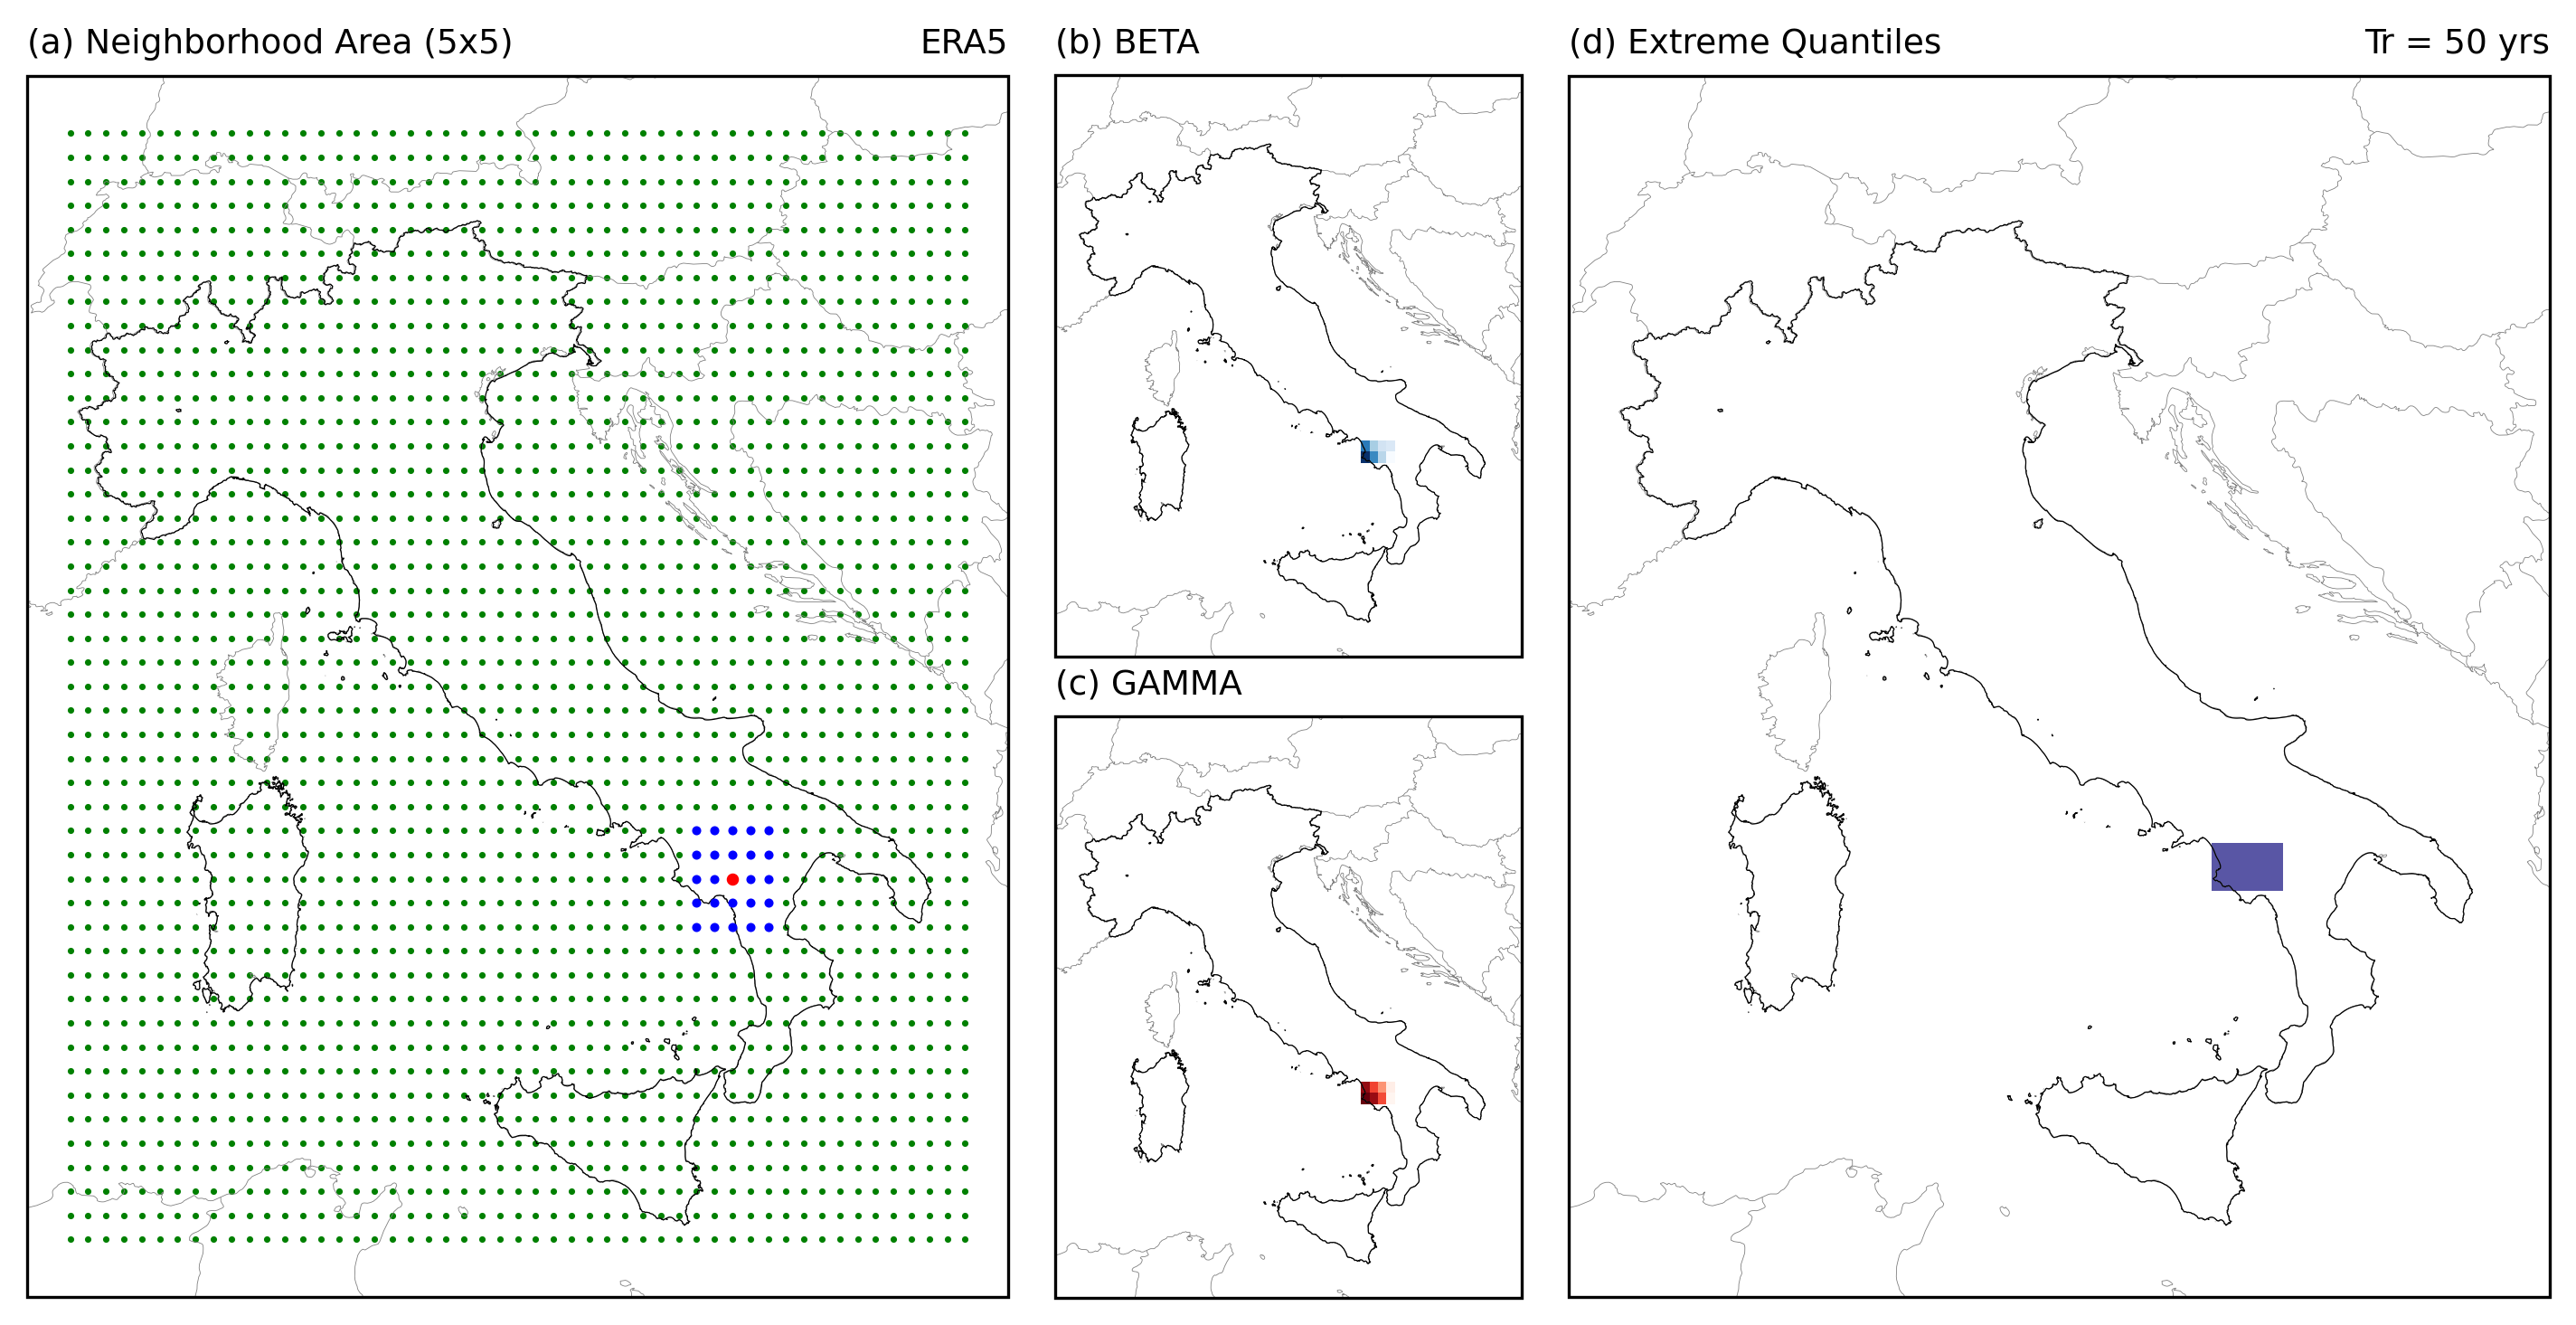

In [133]:

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12,12),dpi=300)
gs = gridspec.GridSpec(4,5)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 0:2], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

ax1.scatter(lon2d, lat2d, s=0.5, c='g', marker='o', label='Study pixels')
ax1.scatter(box_lon2d, box_lat2d, s=2, c='b', label='Box pixels', zorder=50)
ax1.scatter(lon_c, lat_c, s=5 , c='r', label='Central pixel', zorder=55)

ax1.set_title('(a) Neighborhood Area (5x5)', loc='left', fontsize=9)
ax1.set_title('ERA5', loc='right', fontsize=9)

# # ============================================================================================================================

BETA_tmp[i,j] = BETA[i,j]
GAMMA_tmp[i,j] = GAMMA[i,j]
Mev_tmp[i,j] = Mev_d[i,j]

# ============================================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, BETA_tmp, cmap=BETA_cmap)

ax1.set_title('(b) BETA', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[1, 2], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA_tmp, cmap=GAMMA_cmap)

ax1.set_title('(c) GAMMA', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 3:], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, Mev_tmp, cmap=Mev_cmap, norm=norm)

ax1.set_title('(d) Extreme Quantiles', loc='left', fontsize=9)
ax1.set_title('Tr = 50 yrs', loc='right', fontsize=9)

# ============================================================================================================================
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.1, wspace=0.1)

In [ ]:

PRE_daily = PRE_data.resample(time ='D').sum(dim='time', skipna=False)
BOX = ART_pre.create_box_v2(PRE_daily, lat_c, lon_c, 2)
lat_box = BOX['lat'].data
lon_box = BOX['lon'].data
box_lon2d, box_lat2d = np.meshgrid(lon_box, lat_box)

mask = np.full(lat2d.shape, False, dtype=bool)
for la, lo in itertools.product(lat_box, lon_box):
    mask[(lat2d == la) & (lon2d == lo)] = True

BOX2 = BOX.transpose("lon", "lat", "time")
BOX2 = BOX2['PRE']

tscales = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 36, 48, 96])*param['dt']

smax = BOX2.shape[0]
tscales = tscales[tscales < param['tmax'] + 0.001]
xscales = np.arange(1, smax+1)
xscales_km = xscales*param['L1']

WET_MATRIX = ART_pre.space_time_scales_agregations(
            BOX2, 
            param['L1'], 
            param['condition'], 
            tscales, 
            xscales, 
            2*param['npix']+1, 
            param['thresh'])

nxscales = np.size(xscales)

tscales_INTER = np.linspace(np.min(tscales), np.max(tscales), param['ninterp'])
WET_MATRIX_INTER = np.zeros((param['ninterp'], nxscales))

for col in range(nxscales):
    WET_MATRIX_INTER[:, col] = np.interp(tscales_INTER, tscales, WET_MATRIX[:, col])

WET_MATRIX_EXTRA, new_spatial_scale = ART_pre.wet_matrix_extrapolation(
            WET_MATRIX_INTER, 
            xscales_km, 
            tscales_INTER, 
            param['L1'], 
            param['npix'])

vdist, vcorr = ART_pre.autocorrelation_neighborhood_v2(
                    BOX, 
                    time_reso, 
                    param['target_t'], 
                    param['thresh'])

FIT1, _ = curve_fit(ART_down.epl_fun, vdist, vcorr)
xx = np.sort(vdist)

cmap_bin = plt.get_cmap('viridis', 3)  # Use any colormap you like with 2 discrete levels
norm = mcolors.BoundaryNorm([0, 0.5, 1], cmap_bin.N)  

cmap = plt.cm.Spectral_r
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,4),dpi=300)
gs = gridspec.GridSpec(2,2)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:, 0], projection = proj)
# ax1.set_extent([lon_min-1, lon_max+1, lat_min-1, lat_max+1],crs=proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.3,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.3,color='grey')
# VENETO_DEM.plot(facecolor='None', ax=ax1, zorder=10, color='grey', linewidth=0.2, alpha=0.3)
VENETO.plot(facecolor='None', ax=ax1, zorder=10, linewidth=0.8, alpha=0.5)
ax1.add_patch(patches.Rectangle((lon_max,lat_max),lon_min-lon_max,lat_min-lat_max,linestyle='--',linewidth=1,edgecolor='g',facecolor='None',zorder=5))
# ax1.add_patch(patches.Rectangle((lon_max+1,lat_max+1),(lon_min-1)-(lon_max+1),(lat_min-1)-(lat_max+1),linestyle='--',linewidth=2,edgecolor='b',facecolor='None',zorder=5))
gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 4, 'color': 'k'}
gl.ylabel_style = {'size': 4, 'color': 'k'}

a1 = ax1.pcolormesh(lon2d, lat2d, mask, cmap=cmap_bin, norm=norm)

# ax1.scatter(lon2d, lat2d, s=0.1, c='k', marker='o', label='Extended pixels')
ax1.scatter(lon2d_SR, lat2d_SR, s=0.5, c='g', marker='o', label='Study pixels')

ax1.scatter(box_lon2d, box_lat2d, s=0.5, c='b', label='Box pixels', zorder=50)
ax1.scatter(lon_c, lat_c, s=3 , c='r', label='Central pixel', zorder=55)

ax1.plot([],[], color='g',linestyle='--',linewidth=0.5,label='Study region')
# ax1.plot([],[], color='b',linestyle='--',linewidth=2,label='Extended region')

ax1.set_title('(a) Neighborhood Area (5x5)', loc='left', fontsize=7)
ax1.legend(ncol=2, fontsize=5, bbox_to_anchor=(0.85, -0.05))